In [1]:
import re


corpus = """
One fine morning, Tom! Tom! was walking along the Riverside, thinking about everything and nothing.
Suddenly, he shouted: "What are you doing here?" The boy, smiling, kept running, running, and laughing!
Sarah asked politely, "Could you please explain?" but no one responded. Meanwhile, a Flying bird was singing near the School.
The teacher said, "Morning is always the best time for Reading and Writing."
Children were playing, dancing, and enjoying the sunshine. "Really?" asked John.
The girl looked back, wondering, "Why, why would anyone do that?"
After all, caring, sharing, and loving bring meaning to life. Books, music, and games—these things matter!
"""


uppercase_words = re.findall(r'\b[A-Z][a-zA-Z]*\b', corpus)


punctuation = re.findall(r'[.,":?!—]', corpus)

question_sentences = re.findall(r'[^.!?]*\?', corpus)

ing_words = re.findall(r'\b\w+ing\b', corpus)

five_char_words = re.findall(r'\b\w{5}\b', corpus)

quoted_text = re.findall(r'"([^"]*)"', corpus)

words_before_punc = re.findall(r'(\w+)(?=[.,":?!—])', corpus)

morning_sentences = [s.strip() for s in re.split(r'[.!?]', corpus) if "Morning" in s]

repeated_words = re.findall(r'\b(\w+)\b[\s!?,.]+\1\b', corpus)

unique_words = set(re.findall(r'\b\w+\b', corpus.lower()))

function_words = {'a', 'the', 'is', 'and', 'was', 'to', 'for', 'in', 'of', 'on', 'with'}
filtered_corpus = " ".join([w for w in re.findall(r'\b\w+\b', corpus) if w.lower() not in function_words])

unigrams = re.findall(r'\b\w+\b', corpus)
bigrams = [unigrams[i:i+2] for i in range(len(unigrams)-1)]
trigrams = [unigrams[i:i+3] for i in range(len(unigrams)-2)]
sentences = re.split(r'(?<=[.!?])\s+', corpus.strip())

print(f"Uppercase Words: {uppercase_words[:5]}...")
print(f"Quoted Text: {quoted_text}")
print(f"Repeated Words: {repeated_words}")

Uppercase Words: ['One', 'Tom', 'Tom', 'Riverside', 'Suddenly']...
Quoted Text: ['What are you doing here?', 'Could you please explain?', 'Morning is always the best time for Reading and Writing.', 'Really?', 'Why, why would anyone do that?']
Repeated Words: ['Tom', 'running']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


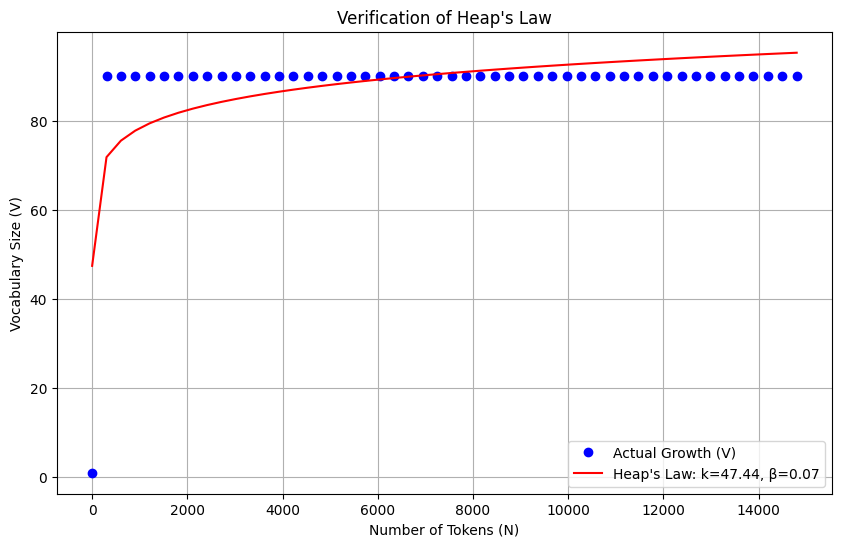

Total Tokens (N): 14800
Unique Word Types (V): 90
Estimated k: 47.4397
Estimated beta (β): 0.0726


In [4]:
import nltk
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')



try:
    with open('corpus.txt', 'r') as f:
        text = f.read()
except FileNotFoundError:
    print("Error: Please upload 'corpus.txt' to the Colab files sidebar.")
    text = ""

if text:

    tokens = word_tokenize(text.lower())
    N_total = len(tokens)
    V_total = len(set(tokens))


    n_steps = np.linspace(1, N_total, 50, dtype=int)
    v_actual = []
    for n in n_steps:
        v_actual.append(len(set(tokens[:n])))


    def heaps_law(N, k, beta):
        return k * (N**beta)


    params, _ = curve_fit(heaps_law, n_steps, v_actual)
    k_est, beta_est = params


    plt.figure(figsize=(10, 6))
    plt.plot(n_steps, v_actual, 'bo', label='Actual Growth (V)')
    plt.plot(n_steps, heaps_law(n_steps, *params), 'r-',
             label=f"Heap's Law: k={k_est:.2f}, β={beta_est:.2f}")

    plt.xlabel('Number of Tokens (N)')
    plt.ylabel('Vocabulary Size (V)')
    plt.title("Verification of Heap's Law")
    plt.legend()
    plt.grid(True)
    plt.show()


    print(f"Total Tokens (N): {N_total}")
    print(f"Unique Word Types (V): {V_total}")
    print(f"Estimated k: {k_est:.4f}")
    print(f"Estimated beta (β): {beta_est:.4f}")